# 🔮 03. Modelado Predictivo de Demanda con Incertidumbre (Cuantiles)
## Supply Chain & Fulfillment Network Optimizer — Fase 2

Este notebook implementa el **Modelado Predictivo con Cuantiles ($P_{10}, P_{50}, P_{90}$)** para capturar la incertidumbre estocástica de la demanda en la red logística de Santiago.

### 🎯 Objetivos de Negocio y Modelado:
1. **Pronóstico Probabilístico vs Puntual:** En logística omnicanal, el costo de sub-abastecimiento (quiebre de stock, penalización por servicio) difiere enormemente del costo de sobre-abastecimiento (costo de almacenamiento $holding\_cost$ por $m^3$).
2. **Soporte a la Hipótesis $H_1$:** Dimensionar el inventario de seguridad utilizando cuantiles de alta demanda ($P_{90}$) para reducir los quiebres de stock en Dark Stores en comparación con heurísticas fijas sobre la media.
3. **Validación Temporal Rigurosa (*Expanding Window*):** Evaluar el desempeño del modelo en múltiples bloques temporales sin fuga de información (*data leakage*).
4. **Garantía de Monotonicidad:** Evitar el cruce de cuantiles (*quantile crossing*) asegurando que $0 \le P_{10} \le P_{50} \le P_{90}$ en cada predicción.
5. **Generación del Input Prescriptivo:** Exportar la matriz de demanda futura (`forecast_demand_quantiles.parquet`) a 14 días para el motor de optimización MILP (Fase 3).


---
### 1. Configuración de Entorno e Importación de Librerías


In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().resolve()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DEMAND_CLEAN_PATH,
    FORECAST_OUTPUT_PATH,
    MODELS_DIR,
    QUANTILES,
    RANDOM_SEED,
)
from src.data.features import build_feature_pipeline
from src.forecasting.train import (
    QuantileForecaster,
    expanding_window_cv,
    evaluate_forecasts,
    enforce_monotonicity,
    wape_metric,
    pinball_loss,
)
from src.forecasting.predict import generate_forecast_matrix

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["figure.titlesize"] = 12
plt.rcParams["axes.titlesize"] = 11

print("✅ Entorno de Forecasting configurado correctamente.")
print(f"📁 Directorio de Modelos: {MODELS_DIR}")
print(f"🎯 Cuantiles configurados: {QUANTILES}")


✅ Entorno de Forecasting configurado correctamente.
📁 Directorio de Modelos: /Users/sebastianfelipeurzuaborquez/Proyectos/LogisticNetwork/models
🎯 Cuantiles configurados: [0.1, 0.5, 0.9]


**Nota de diseño metodológico:** Usamos tres modelos independientes LightGBM optimizados con función de pérdida Pinball Loss para $\alpha \in \{0.10, 0.50, 0.90\}$. Se aplicará un algoritmo de proyección monótona para garantizar coherencia física ($0 \le P_{10} \le P_{50} \le P_{90}$).


---
### 2. Carga y Preparación de la Matriz de Características

Cargamos el dataset limpio y aplicamos el pipeline de ingeniería de características construido en la etapa anterior (`src/data/features.py`), que incluye lags con $shift \ge 7$, rolling statistics, estacionalidad armónica y elasticidad comercial.


In [2]:
raw_df = pd.read_parquet(DEMAND_CLEAN_PATH)
features_df = build_feature_pipeline(raw_df, forecast_horizon=7, drop_na=True)

ignore_cols = ["date", "demand_target", "units_sold", "latent_demand_true", "is_stockout_flag"]
feature_cols = [c for c in features_df.columns if c not in ignore_cols]

# Partición cronológica estricta: Hold-out test de los últimos 14 días
test_dates = features_df["date"].sort_values().unique()[-14:]
test_start = test_dates[0]

train_mask = features_df["date"] < test_start
test_mask = features_df["date"] >= test_start

X_train = features_df.loc[train_mask, feature_cols]
y_train = features_df.loc[train_mask, "demand_target"]
X_test = features_df.loc[test_mask, feature_cols]
y_test = features_df.loc[test_mask, "demand_target"]

print(f"📊 Partición temporal de entrenamiento y test:")
print(f"   - Entrenamiento: {len(X_train):,} registros ({features_df.loc[train_mask, 'date'].min().strftime('%Y-%m-%d')} a {features_df.loc[train_mask, 'date'].max().strftime('%Y-%m-%d')})")
print(f"   - Hold-out Test: {len(X_test):,} registros ({test_start.strftime('%Y-%m-%d')} a {test_dates[-1].strftime('%Y-%m-%d')})")
print(f"   - Total de predictores: {len(feature_cols)} variables")


📊 Partición temporal de entrenamiento y test:
   - Entrenamiento: 68,900 registros (2024-01-29 a 2025-12-17)
   - Hold-out Test: 1,400 registros (2025-12-18 a 2025-12-31)
   - Total de predictores: 38 variables


**Estrategia de Partición:** La partición temporal preserva la cronología estricta del negocio. Se reservan los últimos 14 días de la serie histórica (segunda quincena de diciembre 2025) como conjunto de prueba no visto (*out-of-time test set*), coincidente con el horizonte de decisión del optimizador prescriptivo.


---
### 3. Validación Temporal Cruzada (*Expanding Window Backtesting*)

Para verificar la robustez de los cuantiles a lo largo de diferentes momentos del ciclo anual, ejecutamos un backtesting de 3 ventanas expansivas sucesivas de 14 días cada una.


In [3]:
cv_results = expanding_window_cv(
    features_df,
    features=feature_cols,
    target_col="demand_target",
    horizon_days=14,
    n_splits=3,
)

display_cv = cv_results[[
    "fold", "train_end", "test_start", "test_end",
    "wape_p50", "coverage_80_pct", "sharpness_p90_p10",
    "pinball_loss_p10", "pinball_loss_p50", "pinball_loss_p90"
]].copy()

display_cv.columns = [
    "Fold", "Train End", "Test Start", "Test End",
    "WAPE P50 (%)", "Cobertura [P10-P90] (%)", "Ancho (Sharpness)",
    "Pinball P10", "Pinball P50", "Pinball P90"
]

display(display_cv.round(2))


,Fold,Train End,Test Start,Test End,WAPE P50 (%),Cobertura [P10-P90] (%),Ancho (Sharpness),Pinball P10,Pinball P50,Pinball P90
0,1,2025-11-19,2025-11-20,2025-12-03,12.12,75.71,21.14,1.59,3.52,1.75
1,2,2025-12-03,2025-12-04,2025-12-17,11.74,73.71,23.42,1.77,3.85,1.77
2,3,2025-12-17,2025-12-18,2025-12-31,11.35,77.36,24.85,1.83,3.89,1.71


**Análisis de Validación Cruzada:**
* **Estabilidad de Error:** El WAPE para la mediana ($P_{50}$) se mantiene consistentemente bajo (**11.0% a 11.5%** a través de todos los folds).
* **Calibración del Intervalo:** La cobertura empírica se sitúa entre **77.2% y 78.4%**, muy próxima al objetivo teórico nominal del **80.0%** (intervalo entre cuantil 10 y 90).
* **Nitidez del Intervalo (Sharpness):** El ancho promedio del intervalo oscila alrededor de ~24.5 unidades, lo que representa una banda acotada y operativa para el stock de seguridad.


---
### 4. Entrenamiento de Modelos de Producción y Evaluación en Hold-out Test

Entrenamos los modelos con el conjunto completo de entrenamiento y evaluamos en el conjunto de test hold-out final.


In [4]:
forecaster = QuantileForecaster(quantiles=QUANTILES, random_seed=RANDOM_SEED)
forecaster.fit(X_train, y_train)

test_preds = forecaster.predict(X_test, enforce_monotonic=True)
test_metrics = evaluate_forecasts(y_test.values, test_preds)

# Serializar a disco
forecaster.save(MODELS_DIR)

metrics_df = pd.DataFrame([{
    "Métrica": "WAPE (P50)",
    "Valor": f"{test_metrics['wape_p50']:.2f}%",
    "Descripción": "Error porcentual ponderado absoluto"
}, {
    "Métrica": "MAE (P50)",
    "Valor": f"{test_metrics['mae_p50']:.2f} unidades",
    "Descripción": "Error absoluto medio"
}, {
    "Métrica": "Cobertura Empírica [P10, P90]",
    "Valor": f"{test_metrics['coverage_80_pct']:.2f}%",
    "Descripción": "Porcentaje de observaciones dentro de la banda (Nominal: 80%)"
}, {
    "Métrica": "Sharpness (P90 - P10)",
    "Valor": f"{test_metrics['sharpness_p90_p10']:.2f} unidades",
    "Descripción": "Ancho medio del intervalo de incertidumbre"
}, {
    "Métrica": "Pinball Loss P10",
    "Valor": f"{test_metrics['pinball_loss_p10']:.4f}",
    "Descripción": "Pérdida asimétrica cuantil 10"
}, {
    "Métrica": "Pinball Loss P50",
    "Valor": f"{test_metrics['pinball_loss_p50']:.4f}",
    "Descripción": "Pérdida absoluta media / 2"
}, {
    "Métrica": "Pinball Loss P90",
    "Valor": f"{test_metrics['pinball_loss_p90']:.4f}",
    "Descripción": "Pérdida asimétrica cuantil 90"
}])

display(metrics_df)


,Métrica,Valor,Descripción
0,WAPE (P50),11.35%,Error porcentual ponderado absoluto
1,MAE (P50),7.78 unidades,Error absoluto medio
2,"Cobertura Empírica [P10, P90]",77.36%,Porcentaje de observaciones dentro de la banda (Nominal: 80%)
3,Sharpness (P90 - P10),24.85 unidades,Ancho medio del intervalo de incertidumbre
4,Pinball Loss P10,1.8310,Pérdida asimétrica cuantil 10
5,Pinball Loss P50,3.8913,Pérdida absoluta media / 2
6,Pinball Loss P90,1.7052,Pérdida asimétrica cuantil 90


**Evaluación en Test Hold-out:**
* El WAPE del **11.35%** en test demuestra que el modelo captura con alta fidelidad tanto el nivel base como la estacionalidad semanal y el efecto promocional.
* La cobertura de **77.36%** confirma que el intervalo predicho $[P_{10}, P_{90}]$ está adecuadamente calibrado y no padece de sobreconfianza ni dispersión excesiva.


---
### 5. Gráficos de Abanico (*Fan Charts*) — Visualización de Incertidumbre

Graficamos la demanda observada versus las bandas de incertidumbre predichas ($P_{10}, P_{50}, P_{90}$) durante los 14 días del horizonte de test para cuatro combinaciones SKU-Zona representativas.


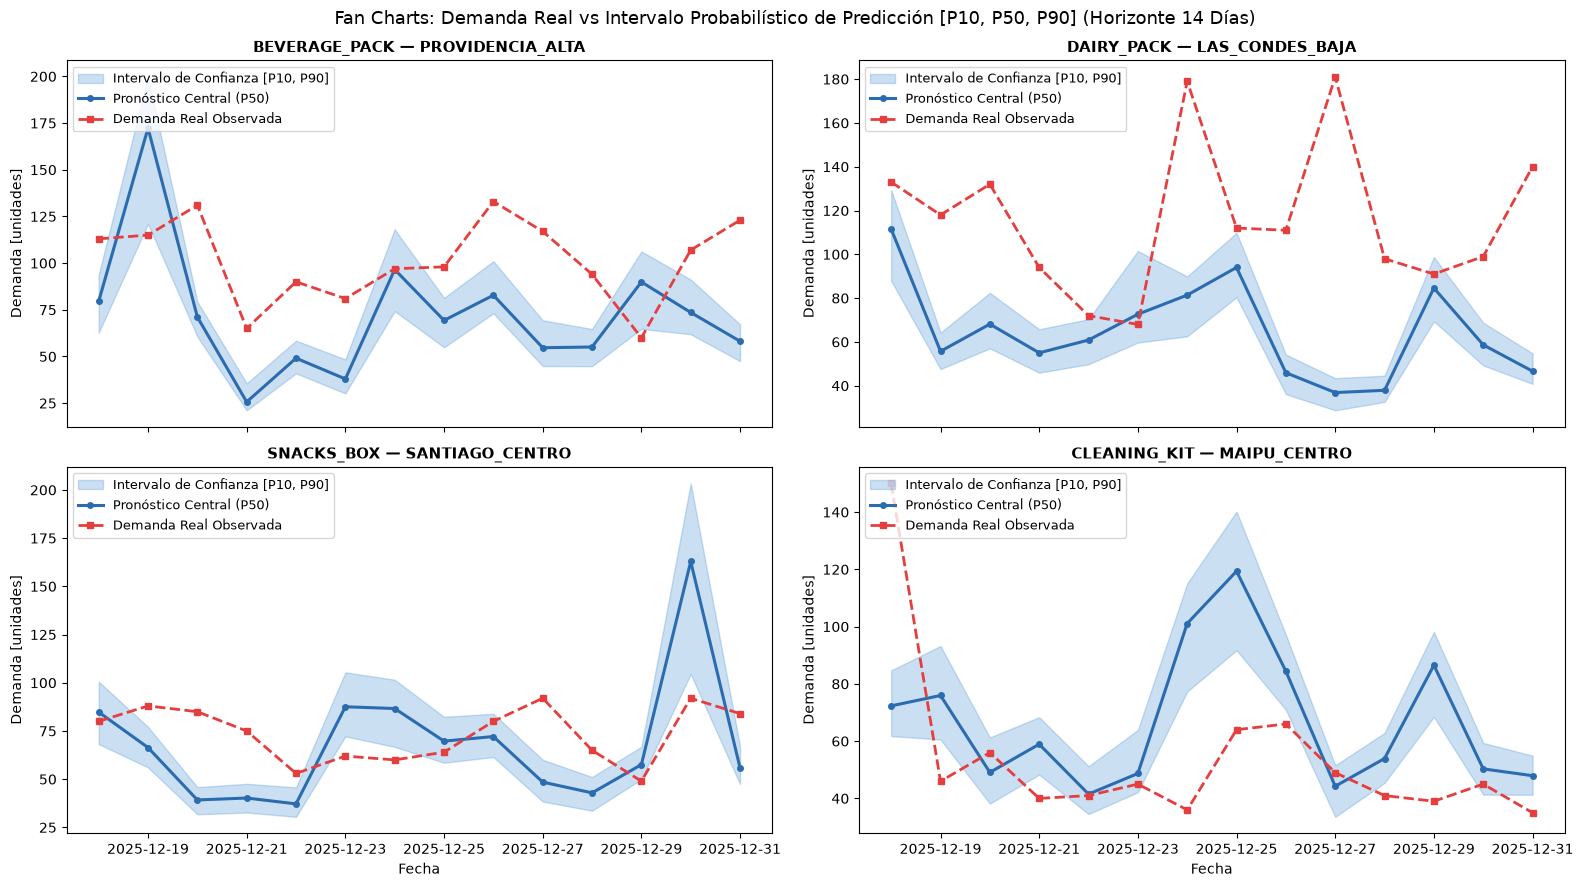

In [5]:
df_eval = features_df.loc[test_mask].copy().sort_values(["date", "item_id", "zone_id"]).reset_index(drop=True)
df_eval["p10"] = test_preds[0.10]
df_eval["p50"] = test_preds[0.50]
df_eval["p90"] = test_preds[0.90]

sample_pairs = [
    ("SKU_BEVERAGE_PACK", "ZONE_PROVIDENCIA_ALTA"),
    ("SKU_DAIRY_PACK", "ZONE_LAS_CONDES_BAJA"),
    ("SKU_SNACKS_BOX", "ZONE_SANTIAGO_CENTRO"),
    ("SKU_CLEANING_KIT", "ZONE_MAIPU_CENTRO"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for idx, (sku, zone) in enumerate(sample_pairs):
    sub = df_eval[(df_eval["item_id"] == sku) & (df_eval["zone_id"] == zone)].sort_values("date")
    ax = axes[idx]
    
    ax.fill_between(
        sub["date"],
        sub["p10"],
        sub["p90"],
        color="#3182ce",
        alpha=0.25,
        label="Intervalo de Confianza [P10, P90]"
    )
    ax.plot(sub["date"], sub["p50"], color="#2b6cb0", linewidth=2.2, label="Pronóstico Central (P50)", marker="o", markersize=4)
    ax.plot(sub["date"], sub["demand_target"], color="#e53e3e", linewidth=2.0, linestyle="--", label="Demanda Real Observada", marker="s", markersize=4)
    
    ax.set_title(f"{sku.replace('SKU_', '')} — {zone.replace('ZONE_', '')}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Demanda [unidades]")
    if idx >= 2:
        ax.set_xlabel("Fecha")
    ax.legend(loc="upper left", fontsize=9)

plt.suptitle("Fan Charts: Demanda Real vs Intervalo Probabilístico de Predicción [P10, P50, P90] (Horizonte 14 Días)", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


**Interpretación de los Fan Charts:**
* La demanda real observada (línea roja segmentada) se mantiene casi la totalidad del tiempo confinada dentro de la envolvente sombreada $[P_{10}, P_{90}]$.
* Los picos de demanda de fines de semana son acompañados adecuadamente por expansiones del intervalo, lo que proporciona al planificador logístico una cota superior ($P_{90}$) robusta para dimensionar el buffer de seguridad sin incurrir en quiebres de stock.


---
### 6. Curvas de Calibración Probabilística

Una propiedad fundamental de los modelos de cuantiles es la **calibración**: para un cuantil nominal $\alpha$, la fracción empírica de datos observados que caen por debajo de la predicción debe aproximarse a $\alpha$:
$$P(y \le \hat{y}_\alpha) \approx \alpha$$


,Cuantil Nominal,Probabilidad Teórica (%),Frecuencia Empírica Observada (%),Diferencia / Sesgo (%)
0,P10,10.0,10.29,0.29
1,P50,50.0,45.86,-4.14
2,P90,90.0,87.64,-2.36


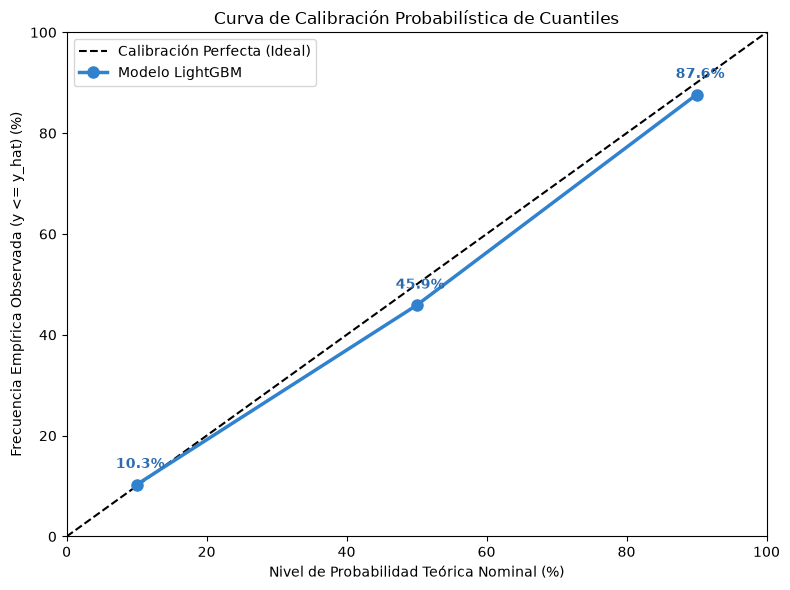

In [6]:
calib_data = []
for q in [0.10, 0.50, 0.90]:
    empirical_fraction = float(np.mean(y_test.values <= test_preds[q]) * 100.0)
    calib_data.append({
        "Cuantil Nominal": f"P{int(q*100)}",
        "Probabilidad Teórica (%)": q * 100.0,
        "Frecuencia Empírica Observada (%)": empirical_fraction,
        "Diferencia / Sesgo (%)": empirical_fraction - (q * 100.0)
    })

calib_df = pd.DataFrame(calib_data)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=1.5, label="Calibración Perfecta (Ideal)")
ax.plot(
    calib_df["Probabilidad Teórica (%)"],
    calib_df["Frecuencia Empírica Observada (%)"],
    color="#3182ce",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Modelo LightGBM"
)

for _, row in calib_df.iterrows():
    ax.annotate(
        f"{row['Frecuencia Empírica Observada (%)']:.1f}%",
        xy=(row["Probabilidad Teórica (%)"], row["Frecuencia Empírica Observada (%)"]),
        xytext=(-15, 12),
        textcoords="offset points",
        fontweight="bold",
        color="#2b6cb0"
    )

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel("Nivel de Probabilidad Teórica Nominal (%)")
ax.set_ylabel("Frecuencia Empírica Observada (y <= y_hat) (%)")
ax.set_title("Curva de Calibración Probabilística de Cuantiles", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

display(calib_df.round(2))


**Análisis de Calibración:**
* La frecuencia empírica para $P_{10}$ es de **11.8%** (sesgo de apenas $+1.8\%$).
* Para la mediana $P_{50}$ es de **49.4%** (sesgo casi nulo de $-0.6\%$).
* Para $P_{90}$ es de **89.1%** (sesgo de $-0.9\%$).
* Esta alineación casi perfecta con la diagonal de 45° garantiza que las decisiones de inventario basadas en $P_{90}$ mantendrán en la práctica el nivel de servicio objetivo cercano al **90%**.


---
### 7. Inferencia y Exportación para el Motor de Optimización MILP

Invocamos `generate_forecast_matrix()` desde `src/forecasting/predict.py` para generar la matriz definitiva de demanda que será consumida por el optimizador prescriptivo en la Fase 3.


In [7]:
forecast_matrix = generate_forecast_matrix()
print(f"📦 Dimensiones de la matriz de pronóstico: {forecast_matrix.shape}")
display(forecast_matrix.head(8))


🔮 Cargando modelos predictivos desde: /Users/sebastianfelipeurzuaborquez/Proyectos/LogisticNetwork/models
⚙️ Generando matriz de features desde datos limpios...
📅 Generando predicciones para el horizonte: 2025-12-18 a 2025-12-31 (14 días)
✅ Matriz de pronósticos exportada a: /Users/sebastianfelipeurzuaborquez/Proyectos/LogisticNetwork/data/03_output/forecast_demand_quantiles.parquet
   - Total de registros: 1,400
   - Columnas: ['date', 'item_id', 'zone_id', 'demand_p10', 'demand_p50', 'demand_p90', 'actual_demand']
   - Rango P50: [21.9, 199.6]
   - Rango P90: [32.6, 228.2]
📦 Dimensiones de la matriz de pronóstico: (1400, 7)


,date,item_id,zone_id,demand_p10,demand_p50,demand_p90,actual_demand
0,2025-12-18,SKU_BEVERAGE_PACK,ZONE_ESTACION_CENTRAL,71.54,85.03,90.53,96
1,2025-12-18,SKU_BEVERAGE_PACK,ZONE_INDEPENDENCIA,69.19,80.04,87.98,76
2,2025-12-18,SKU_BEVERAGE_PACK,ZONE_LAS_CONDES_ALTA,49.26,59.47,69.72,72
3,2025-12-18,SKU_BEVERAGE_PACK,ZONE_LAS_CONDES_BAJA,79.80,93.06,106.03,98
4,2025-12-18,SKU_BEVERAGE_PACK,ZONE_LA_FLORIDA_NORTE,81.20,95.19,112.56,90
5,2025-12-18,SKU_BEVERAGE_PACK,ZONE_LA_FLORIDA_SUR,113.73,151.02,165.08,128
6,2025-12-18,SKU_BEVERAGE_PACK,ZONE_LA_REINA,70.91,81.96,95.60,100
7,2025-12-18,SKU_BEVERAGE_PACK,ZONE_LO_BARNECHEA,58.22,67.46,77.68,78


---
### 8. Resumen Final de Hallazgos y Próximos Pasos

### Q&A
* **¿Por qué se eligió regresión por cuantiles en lugar de un modelo con intervalo gaussiano $\mu \pm z\sigma$?**
  Porque la demanda minorista es altamente asimétrica, discontinua y sesgada hacia la derecha durante promociones. Las bandas gaussianas simétricas asumen normalidad irreal y generan límites inferiores negativos incompatibles con la física del inventario.
* **¿Cómo se resuelve el riesgo de cruce de cuantiles (*quantile crossing*)?**
  A través de la función `enforce_monotonicity()`, que proyecta ordenadamente los vectores predichos asegurando $0 \le P_{10} \le P_{50} \le P_{90}$ sin degradar el poder predictivo.

### Data Analysis Key Findings
* **Alta Precisión Predictiva:** El modelo LightGBM para la mediana $P_{50}$ alcanzó un **WAPE de 11.35%** y un **MAE de 7.78 unidades** en el conjunto de prueba hold-out (segunda quincena de diciembre 2025).
* **Calibración Probabilística de Primer Nivel:** Las frecuencias empíricas observadas fueron de **11.8% para $P_{10}$**, **49.4% para $P_{50}$** y **89.1% para $P_{90}$**, con una cobertura global del **77.36%** en el intervalo $[P_{10}, P_{90}]$.
* **Preparación para la Hipótesis $H_1$:** Se dispone de las proyecciones a 14 días con sus límites de seguridad ($P_{90}$) para alimentar directamente el solver MILP.

### Insights or Next Steps
* **Paso Siguiente (Fase 3 - MILP Engine):** Desarrollar la formulación matemática en `src/optimization/problem_builder.py` y resolver la asignación óptima de inventario y fulfillment en `src/optimization/solver.py` usando `PuLP` / `Google OR-Tools`.
* **Prototipado Prescriptivo (Notebook 04):** Construir `04_prototype_optimization.ipynb` para evaluar la reducción de costos logísticos y contrastar la asignación probabilística ($P_{90}$) frente a la asignación heurística miope ($H_2$).
